# Analyse de cohortes — Online Retail II

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

sys.path.append(str(Path("..").resolve()))

from src.load_data import charger_ventes_en_ligne
from src.clean_transactions import nettoyer_transactions
from src.cohorts import (
    ajouter_cohortes,
    construire_table_retention,
    revenu_moyen_par_cohorte,
)

donnees = charger_ventes_en_ligne()
donnees = nettoyer_transactions(donnees)

ventes_cohortes = ajouter_cohortes(donnees)
retention = construire_table_retention(ventes_cohortes)
retention.round(2)

cohort_index,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
cohort_month,,,,,,,,,,,,,,,,,,,,,
2009-12-01,1.0,0.35,0.33,0.43,0.38,0.36,0.38,0.34,0.34,0.36,...,0.30,0.26,0.30,0.28,0.26,0.26,0.32,0.30,0.41,0.2
2010-01-01,1.0,0.21,0.31,0.31,0.26,0.30,0.26,0.23,0.28,0.32,...,0.15,0.23,0.20,0.19,0.20,0.24,0.19,0.25,0.06,0.0
2010-02-01,1.0,0.24,0.22,0.29,0.24,0.20,0.19,0.28,0.25,0.27,...,0.20,0.16,0.16,0.14,0.23,0.23,0.16,0.06,0.00,0.0
2010-03-01,1.0,0.19,0.23,0.24,0.23,0.20,0.25,0.30,0.28,0.11,...,0.17,0.17,0.16,0.18,0.20,0.21,0.08,0.00,0.00,0.0
2010-04-01,1.0,0.19,0.19,0.16,0.18,0.22,0.28,0.26,0.11,0.11,...,0.16,0.14,0.15,0.18,0.22,0.06,0.00,0.00,0.00,0.0
2010-05-01,1.0,0.16,0.17,0.17,0.18,0.26,0.21,0.13,0.06,0.08,...,0.13,0.14,0.17,0.15,0.05,0.00,0.00,0.00,0.00,0.0
2010-06-01,1.0,0.17,0.19,0.20,0.23,0.29,0.13,0.09,0.08,0.12,...,0.12,0.13,0.20,0.05,0.00,0.00,0.00,0.00,0.00,0.0
2010-07-01,1.0,0.16,0.18,0.30,0.29,0.14,0.11,0.15,0.15,0.11,...,0.17,0.24,0.08,0.00,0.00,0.00,0.00,0.00,0.00,0.0
2010-08-01,1.0,0.20,0.30,0.32,0.17,0.12,0.10,0.12,0.14,0.13,...,0.20,0.07,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0


## Matrice de rétention (carte de chaleur)

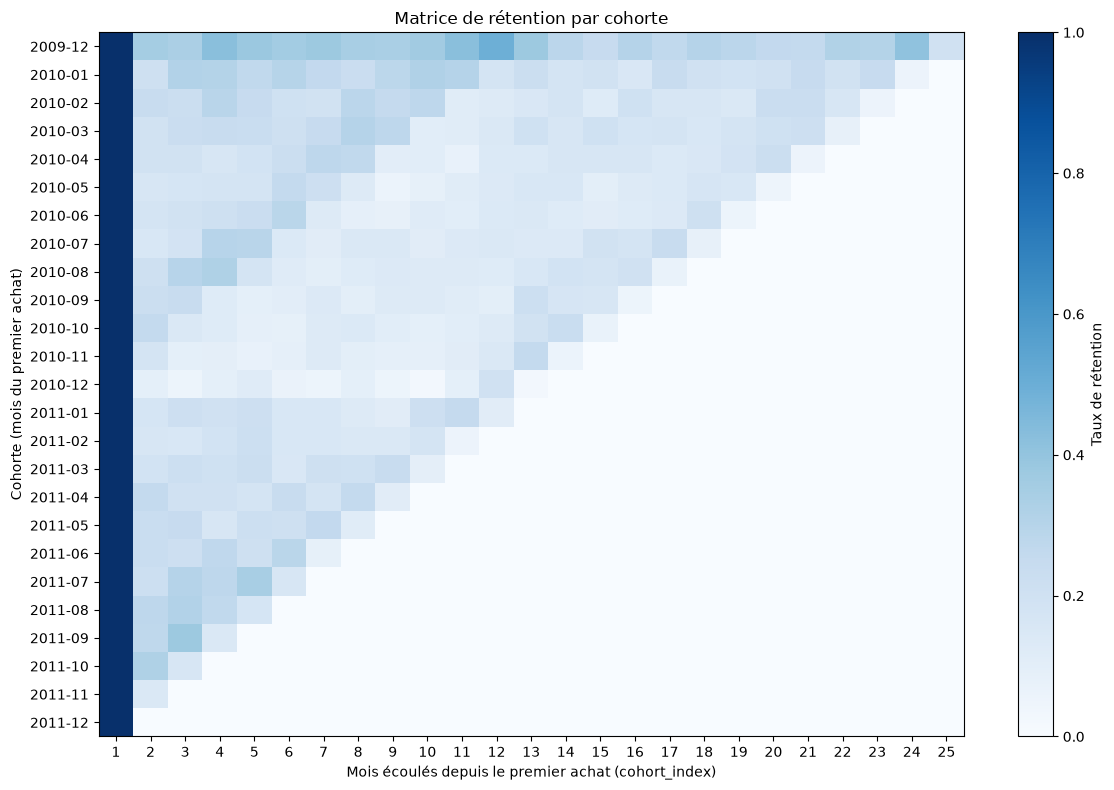

In [2]:
plt.figure(figsize=(12, 8))
plt.imshow(retention, aspect="auto", cmap="Blues")
plt.colorbar(label="Taux de rétention")
plt.xlabel("Mois écoulés depuis le premier achat (cohort_index)")
plt.ylabel("Cohorte (mois du premier achat)")
plt.yticks(range(len(retention.index)), retention.index.strftime("%Y-%m"))
plt.xticks(range(len(retention.columns)), retention.columns)
plt.title("Matrice de rétention par cohorte")
plt.tight_layout()
plt.show()

## Rétention moyenne après 1, 3 et 6 mois

`cohort_index = 1` correspond au mois d'acquisition lui-même (0 mois
écoulé) ; `cohort_index = 2` correspond donc à 1 mois écoulé, etc.

In [3]:
for libelle, index in [("1 mois", 2), ("3 mois", 4), ("6 mois", 7)]:
    if index in retention.columns:
        valeur_moyenne = retention[index].mean()
        print(f"Rétention moyenne après {libelle} : {valeur_moyenne:.1%}")
    else:
        print(f"Pas assez de recul dans les données pour mesurer {libelle}")

Rétention moyenne après 1 mois : 20.3%
Rétention moyenne après 3 mois : 19.0%
Rétention moyenne après 6 mois : 13.5%


## Cohortes avec la meilleure rétention à 1 mois

In [5]:
if 2 in retention.columns:
    retention[2].sort_values(ascending=False).head(5)

## Revenu moyen par client, par cohorte et par mois écoulé

In [6]:
revenu_cohortes = revenu_moyen_par_cohorte(ventes_cohortes)
revenu_cohortes.head(10)

,cohort_month,cohort_index,revenu_total,clients_actifs,revenu_moyen_par_client
0,2009-12-01,1,686654.160,955,719.009592
1,2009-12-01,2,395425.571,337,1173.369647
2,2009-12-01,3,296802.132,319,930.414207
3,2009-12-01,4,379654.490,406,935.109581
4,2009-12-01,5,306885.820,363,845.415482
5,2009-12-01,6,305953.890,343,891.993848
6,2009-12-01,7,302857.560,360,841.271000
7,2009-12-01,8,313502.730,327,958.723945
8,2009-12-01,9,332498.840,321,1035.821931
9,2009-12-01,10,392636.020,346,1134.786185


## Export

In [7]:
retention.to_csv(Path("../data/processed/cohort_retention.csv"))
print("Fichier exporté : data/processed/cohort_retention.csv")

Fichier exporté : data/processed/cohort_retention.csv
